# Задача: выявить корреляцию (или ее отсутствие) между размером словаря токенизатора и качеством модели (выраженном в f1) для задачи сентимент-анализа.
Предлагаемый план работ:
1. Ознакомиться с документацией и реализовать LightningDataModule (https://lightning.ai/docs/pytorch/stable/data/datamodule.html)
 - Загрузить датасет
 - Провести предобработку
 - Выбрать токенизатор (BPE, WordPiece, Unigram)
 - Реализовать collate_fn функцию токенизации для даталодера - encode
 - Добавить даталодеры
2. Ознакомиться с документацией и реализовать LightningModule (https://lightning.ai/docs/pytorch/LTS/common/lightning_module.html)
 - Выбрать и реализовать подходящую архитектуру модели для сентимент-анализа текста
 - Написать прямой проход модели
 - Написать training_step, validation_step, test_step
3. Провести цикл обучений модели
 - Ознакомиться с документацией и выбрать оптимальные настройки для Trainer (https://lightning.ai/docs/pytorch/stable//common/trainer.html)
 - Зафиксировать все гиперпараметры и провести обучение-валидацию-тестирование для 5 значений размера словаря (выбранных на ваше усмотрение)
 - Полученные результаты представить в виде гистограммы или любой другой визуализации

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

import pytorch_lightning as pl
import lightning.pytorch as pl
from tokenizers import Tokenizer, models, trainers, pre_tokenizers
from typing import *
import torchmetrics
import pandas as pd
from datasets import Dataset, DatasetDict
from lightning import seed_everything
from tqdm.auto import tqdm

/home/lezchook/miniconda3/envs/env1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data

In [ ]:
class MyDataModule(pl.LightningDataModule):
    def __init__(
        self,
        negative_file: str,
        positive_file: str,
        batch_size: int = 2048,
        num_workers: int = 0,
        vocab_size: int = 1000,
        max_length: int = 256,
    ):
        super().__init__()
        self.negative_file = negative_file
        self.positive_file = positive_file
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.vocab_size = vocab_size
        self.max_length = max_length

    def prepare_data(self):
        negative_df = pd.read_csv(self.negative_file, delimiter=";", header=None,
                                  names=["id", "tdate", "tmane", 'ttext', 'ttype', 'trep', 'trtv',
                                         'tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'])
        positive_df = pd.read_csv(self.positive_file, delimiter=";", header=None,
                                  names=["id", "tdate", "tmane", 'ttext', 'ttype', 'trep', 'trtv',
                                         'tfav', 'tstcount', 'tfol', 'tfrien', 'listcount'])

        df = pd.concat([negative_df, positive_df]).reset_index(drop=True)
        df = df[['ttext', 'ttype']]
        df = df.rename(columns={'ttext': 'text', 'ttype': 'label'})
        df['label'] = df['label'].apply(lambda x: 0 if x < 0 else 1)

        train_df, val_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
        val_df, test_df = train_test_split(val_df, test_size=0.5, stratify=val_df['label'], random_state=42)

        self.ds = DatasetDict({
            "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
            "val": Dataset.from_pandas(val_df.reset_index(drop=True)),
            "test": Dataset.from_pandas(test_df.reset_index(drop=True))
        })

    def setup(self, stage=None):
        model = models.Unigram()
        trainer = trainers.UnigramTrainer(
            vocab_size=self.vocab_size,
            special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"],
            unk_token="[UNK]"
        )
        tokenizer = Tokenizer(model)
        tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
        tokenizer.train_from_iterator(self.ds["train"]["text"], trainer=trainer)

        tokenizer.enable_truncation(self.max_length)
        tokenizer.enable_padding(pad_token="[PAD]", direction="left")

        self.pad_id = tokenizer.token_to_id("[PAD]")

        def encode(batch):
            encodings = tokenizer.encode_batch(batch["text"])
            return {
                "input_ids": [enc.ids for enc in encodings],
                "label": batch["label"]
            }

        self.ds = self.ds.map(encode, batched=True, remove_columns=["text"])
    
    def collate_fn(self, batch):
        input_ids = [torch.tensor(item["input_ids"]) for item in batch]
        input_ids = pad_sequence(input_ids, batch_first=True, padding_value=self.pad_id)
        labels = torch.tensor([item["label"] for item in batch], dtype=torch.long)
        return {"input_ids": input_ids, "labels": labels}

    def train_dataloader(self):
        return DataLoader(
            self.ds["train"],
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            collate_fn=self.collate_fn
        )

    def val_dataloader(self):
        return DataLoader(
            self.ds["val"],
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            collate_fn=self.collate_fn
        )
    
    def test_dataloader(self):
        return DataLoader(
            self.ds["test"],
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            collate_fn=self.collate_fn
        )

# Model

In [3]:
class RNNModel(pl.LightningModule):
    def __init__(self, vocab_size, embd_size, hidden_size, output_size, pad_id):
        super(RNNModel, self).__init__()

        self.save_hyperparameters()

        self.embedding = nn.Embedding(vocab_size, embd_size, padding_idx=pad_id)
        self.lstm = nn.LSTM(embd_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

        self.loss_fn = nn.CrossEntropyLoss()

        self.train_f1 = torchmetrics.F1Score(task="multiclass", num_classes=output_size, average="macro")
        self.val_f1 = torchmetrics.F1Score(task="multiclass", num_classes=output_size, average="macro")
        self.test_f1 = torchmetrics.F1Score(task="multiclass", num_classes=output_size, average="macro")

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        output, (hn, _) = self.lstm(embedded)
        out = self.fc(hn[-1])
        return out

    def training_step(self, batch, batch_idx):
        input_ids, labels = batch["input_ids"], batch["labels"]
        logits = self(input_ids)
        loss = self.loss_fn(logits, labels)

        preds = torch.argmax(logits, dim=1)
        f1 = self.train_f1(preds, labels)

        self.log("train_loss", loss, on_step=False, on_epoch=True)
        self.log("train_f1", f1, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        input_ids, labels = batch["input_ids"], batch["labels"]
        logits = self(input_ids)
        loss = self.loss_fn(logits, labels)

        preds = torch.argmax(logits, dim=1)
        f1 = self.val_f1(preds, labels)

        self.log("val_loss", loss, on_epoch=True)
        self.log("val_f1", f1, on_epoch=True)
        return loss

    def test_step(self, batch, batch_idx):
        input_ids, labels = batch["input_ids"], batch["labels"]
        logits = self(input_ids)
        loss = self.loss_fn(logits, labels)

        preds = torch.argmax(logits, dim=1)
        f1 = self.test_f1(preds, labels)

        self.log("test_loss", loss, prog_bar=True)
        self.log("test_f1", f1, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        train_loss = self.trainer.callback_metrics.get("train_loss")
        train_f1 = self.trainer.callback_metrics.get("train_f1")
        if train_loss is not None:
            print(f" Training Loss: {train_loss:.4f} Training F1-score: {train_f1}")

            
    def on_validation_epoch_end(self):
        val_loss = self.trainer.callback_metrics.get("val_loss")
        val_f1 = self.trainer.callback_metrics.get("val_f1")
        if val_loss is not None:
            print(f" Validation Loss: {val_loss:.4f} Validation F1-score: {val_f1}")

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

# Trainer

In [4]:
f1_score_results = []
vocab_sizes = [1000, 1200, 1400, 1600, 1800, 2000]
max_length = 256
embd_size = 256
hidden_size = 256
negative_file = "/home/lezchook/NLP_lab/negative.csv"
positive_file = "/home/lezchook/NLP_lab/positive.csv"

for size in vocab_sizes:
    seed_everything(42)
    dm = MyDataModule(negative_file=negative_file, positive_file=positive_file, vocab_size=size, max_length=max_length)
    dm.prepare_data()
    dm.setup()

    seed_everything(42)
    model = RNNModel(vocab_size=size, embd_size=embd_size, hidden_size=hidden_size, output_size=2, pad_id=dm.pad_id)
    trainer = pl.Trainer(max_epochs=2, deterministic=True)
    trainer.fit(model=model, datamodule=dm)
    f1_score = trainer.test(datamodule=dm, ckpt_path="best")[0]["test_f1"]
    f1_score_results.append(f1_score)

Seed set to 42


Map: 100%|██████████| 34026/34026 [00:01<00:00, 24452.43 examples/s]
Seed set to 42
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/lezchook/miniconda3/envs/env1/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
You are using a CUDA device ('NVIDIA GeForce RTX 3050') that has Tensor Cores. To properly ut

Map: 100%|██████████| 34026/34026 [00:01<00:00, 24944.89 examples/s]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | embedding | Embedding         | 256 K  | train
1 | lstm      | LSTM              | 526 K  | train
2 | fc        | Linear            | 514    | train
3 | loss_fn   | CrossEntropyLoss  | 0      | train
4 | train_f1  | MulticlassF1Score | 0      | train
5 | val_f1    | MulticlassF1Score | 0      | train
6 | test_f1   | MulticlassF1Score | 0      | train
--------------------------------------------------------
782 K     Trainable params
0         Non-trainable params
782 K     Total params
3.131     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/home/lezchook/miniconda3/envs/env1/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


...

Epoch 1: 100%|██████████| 78/78 [00:35<00:00,  2.19it/s, v_num=66]

`Trainer.fit` stopped: `max_epochs=2` reached.


 Training Loss: 0.5639 Training F1-score: 0.5495045781135559
Epoch 1: 100%|██████████| 78/78 [00:35<00:00,  2.19it/s, v_num=66]




Map: 100%|██████████| 34026/34026 [00:01<00:00, 25086.97 examples/s]
Restoring states from the checkpoint path at /home/lezchook/NLP_lab/lightning_logs/version_66/checkpoints/epoch=1-step=156.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/lezchook/NLP_lab/lightning_logs/version_66/checkpoints/epoch=1-step=156.ckpt
/home/lezchook/miniconda3/envs/env1/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 17/17 [00:05<00:00,  2.89it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         test_f1            0.8957383036613464
        test_loss           0.3159843981266022
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


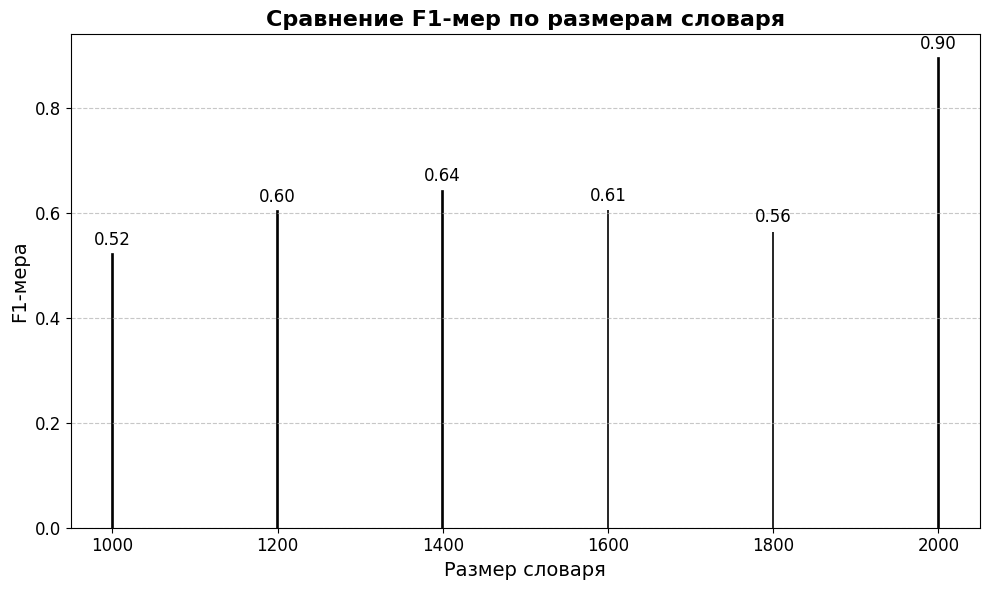

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bars = plt.bar(vocab_sizes, f1_score_results, color='#4C72B0', edgecolor='black', linewidth=1.2)

plt.title('Сравнение F1-мер по размерам словаря', fontsize=16, fontweight='bold')
plt.xlabel('Размер словаря', fontsize=14)
plt.ylabel('F1-мера', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', 
             ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()